# HydroSeason: DEA Acquisition — what happens when you pass an AOI

`run_hydroseason(aoi=..., start_date=..., end_date=...)` fetches Digital
Earth Australia Water Observations for you. This notebook opens that box.

The part worth understanding is **how the analysis area is chosen**. HydroSeason
does not analyse your AOI's bounding box. It first asks DEA's *all-time*
Water Observation Statistics which pixels have **ever** been observed as water,
and analyses only those. That mask becomes the fixed denominator for every
month in your date range — so a month with no satellite coverage is reported
as *unobserved*, not as *dry*.

**Requirements:** `pip install "hydroseason[stac]"`
**Network:** yes — queries the live DEA STAC catalog.
**Runtime:** a few minutes on first run; the acquisition cache makes re-runs fast.

> If you just want results, you do not need any of this — see
> [01_quickstart.ipynb](01_quickstart.ipynb). Everything below happens
> automatically inside `run_hydroseason`.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np

from hydroseason import (
    load_aoi,
    open_wo_statistics,
    load_or_build_historical_water_mask,
    run_hydroseason,
)

AOI_PATH = Path("../data/fitzroy_kimberley_aoi.geojson")

START_DATE = "2015-01-01"
END_DATE = "2025-12-01"

# Everything cached under one directory: the WOfS Zarr store, the historical
# water mask artifact, and the monthly extent CSVs. Delete it to force a
# clean re-fetch.
CACHE_DIR = Path("output/02_dea_cache")
OUTPUT_DIR = Path("output/02_dea_acquisition")

print("AOI:", AOI_PATH.resolve().name)
print("Period:", START_DATE, "to", END_DATE)

AOI: fitzroy_kimberley_aoi.geojson
Period: 2015-01-01 to 2025-12-01


## 2. The AOI

A plain polygon. Note its CRS is EPSG:4326 (degrees) — HydroSeason reprojects
to EPSG:3577 (Australian Albers, metres) internally, because every pixel count
it reports is an area measurement and needs an equal-area grid.

In [2]:
aoi = load_aoi(AOI_PATH)

print(f"Features:      {len(aoi)}")
print(f"CRS:           {aoi.crs}")
print(f"Bounds (deg):  {np.round(aoi.total_bounds, 4)}")

albers = aoi.to_crs("EPSG:3577")
minx, miny, maxx, maxy = albers.total_bounds
print(f"Bounding box:  {(maxx - minx) / 1000:.1f} km x {(maxy - miny) / 1000:.1f} km")
print(f"Polygon area:  {albers.area.sum() / 1e6:.1f} km^2")

Features:      1
CRS:           EPSG:4326
Bounds (deg):  [123.9079 -18.1681 124.217  -18.0402]
Bounding box:  33.5 km x 16.1 km
Polygon area:  448.5 km^2


## 3. DEA WOfS Statistics — where has water *ever* been?

`open_wo_statistics` loads the all-time summary product `ga_ls_wo_fq_myear_3`:
one raster per pixel summarising the entire Landsat WOfS archive.

Two raw count bands are requested, and `frequency` is derived from them
explicitly (`100 * count_wet / count_clear`) rather than trusting an opaque
precomputed band:

| Band | Meaning |
|---|---|
| `count_wet` | how many times this pixel was observed as water |
| `count_clear` | how many cloud/shadow-free observations it had at all |
| `frequency` | derived: percent of clear observations that were wet |

The returned cube is **lazy** (dask-backed) — nothing has been downloaded yet.

In [3]:
stats = open_wo_statistics(AOI_PATH)

provenance = stats.attrs["provenance"]
print(f"Product:    {provenance['product']}")
print(f"Coverage:   {provenance['time_span']}")
print(f"Grid:       {provenance['crs']} @ {provenance['resolution']} m")
print(f"Shape:      {dict(stats.sizes)}")
print(f"Bands:      {list(stats.data_vars)}")
print(f"Lazy?       {hasattr(stats['count_wet'].data, 'compute')}")

Product:    ga_ls_wo_fq_myear_3
Coverage:   1987-01-01T00:00:00Z/2025-12-31T23:59:59.999999Z
Grid:       EPSG:3577 @ 30.0 m
Shape:      {'y': 539, 'x': 1117}
Bands:      ['count_wet', 'count_clear', 'frequency']
Lazy?       True


### What the archive actually saw here

Computing the statistics now (this is the first real download — a single
small summary raster, not the monthly time series).

In [4]:
frequency = stats["frequency"].compute()
count_wet = stats["count_wet"].compute()

ever_wet = (count_wet > 0).values
print(f"Pixels in the bounding grid:  {ever_wet.size:,}")
print(f"Ever observed as water:       {ever_wet.sum():,}  ({100 * ever_wet.mean():.1f}%)")
print()
print("Water frequency of the ever-wet pixels (percent of clear observations):")
wet_freq = frequency.values[ever_wet & np.isfinite(frequency.values)]
for q in (50, 75, 90, 99):
    print(f"  {q}th percentile: {np.percentile(wet_freq, q):6.1f}%")
print(f"  maximum:         {wet_freq.max():6.1f}%   <- permanent water")

Pixels in the bounding grid:  602,063
Ever observed as water:       349,566  (58.1%)

Water frequency of the ever-wet pixels (percent of clear observations):
  50th percentile:    1.3%
  75th percentile:    2.3%
  90th percentile:    3.6%
  99th percentile:   41.6%
  maximum:           98.6%   <- permanent water


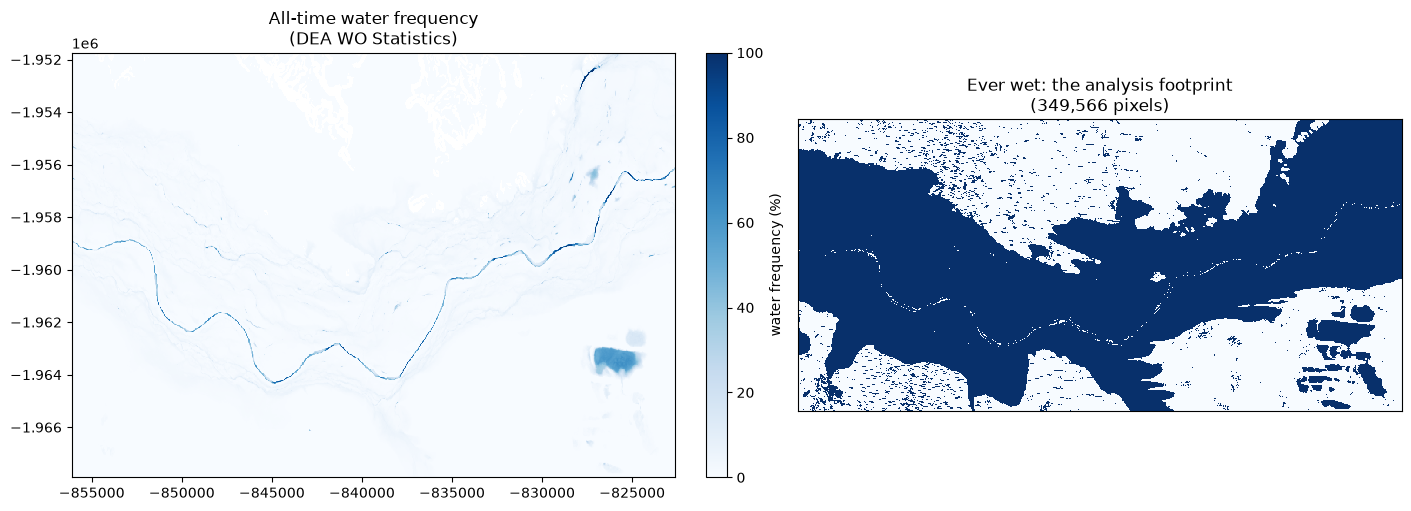

In [5]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    print("matplotlib not installed; skipping the map.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    frequency.plot(ax=axes[0], cmap="Blues", vmin=0, vmax=100,
                   cbar_kwargs={"label": "water frequency (%)"})
    axes[0].set_title("All-time water frequency\n(DEA WO Statistics)")

    axes[1].imshow(ever_wet, cmap="Blues", interpolation="nearest")
    axes[1].set_title(f"Ever wet: the analysis footprint\n({ever_wet.sum():,} pixels)")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
    plt.show()

## 4. The historical water mask — shrinking the AOI to what matters

`load_or_build_historical_water_mask` turns those statistics into the exact
analysis mask: **`(count_wet > 0) AND your AOI`**, at the native 30 m grid.

This is the part that makes the AOI smaller. It is used two ways, and the
distinction matters:

1. **As the scientific denominator.** Its `pixel_count` is the fixed `n_aoi`
   for *every* month. Extent percentages are "percent of the historically
   wet area", not "percent of a rectangle mostly made of dry land" — so the
   numbers stay comparable across months and across catchments.
2. **As a read-planning aid**, to skip downloading tiles that provably contain
   no water (section 5).

It is never buffered, smoothed, or round-tripped through a polygon — it is the
raw boolean raster, cached with a content digest so a later run reuses the
identical mask rather than rebuilding a subtly different one.

In [6]:
mask = load_or_build_historical_water_mask(
    AOI_PATH,
    analysis_end=END_DATE,
    cache_root=CACHE_DIR,
)

grid_cells = int(np.prod(mask.shape))

print(f"Grid:              {mask.shape[0]} x {mask.shape[1]} = {grid_cells:,} cells")
print(f"Analysed pixels:   {mask.pixel_count:,}")
print(f"Skipped as dry:    {grid_cells - mask.pixel_count:,}")
print()
print(f"The mask analyses {100 * mask.pixel_count / grid_cells:.1f}% of the bounding grid,")
print(f"i.e. it discards {100 * (1 - mask.pixel_count / grid_cells):.1f}% of it as never-wet land.")
print()
print(f"Fixed area:        {mask.pixel_count * 30 * 30 / 1e6:.1f} km^2 (30 m pixels)")
print(f"Source:            {mask.source_product}")
print(f"Source coverage:   {mask.coverage_start[:10]} to {mask.coverage_end[:10]}")
print(f"Mask digest:       {mask.mask_sha256[:16]}...")

Grid:              539 x 1117 = 602,063 cells
Analysed pixels:   324,757
Skipped as dry:    277,306

The mask analyses 53.9% of the bounding grid,
i.e. it discards 46.1% of it as never-wet land.

Fixed area:        292.3 km^2 (30 m pixels)
Source:            ga_ls_wo_fq_myear_3
Source coverage:   1987-01-01 to 2025-12-31
Mask digest:       35c927c2eeb102f4...


> **Why this is a denominator, not a filter.** Every month is measured against
> the same `pixel_count`. A month where cloud hid half the catchment reports a
> high `invalid_pct` and a correspondingly uncertain `extent_pct` — it does not
> silently shrink the denominator and report a falsely confident number. A month
> with no usable satellite pass at all reports 100% invalid rather than 0% water.

## 5. Planning footprint — not downloading what cannot be wet

The same mask is coarsened and dilated into a conservative read plan. This is
**performance only**: it decides which storage windows get fetched, never which
pixels count. It is deliberately a superset — max-pooled, never averaged, plus a
safety halo — so an isolated wet pixel can never be pruned away.

In [7]:
from hydroseason._io_dea_stats import build_planning_footprint_from_historical_mask

footprint = build_planning_footprint_from_historical_mask(mask)

native = np.asarray(footprint.native_mask.values, dtype=bool)
coarse = np.asarray(footprint.coarse_mask.values, dtype=bool)

print(f"Coarsening factor:   {footprint.factor}x  (+ {footprint.safety_cells}-cell safety halo)")
print(f"Exact mask cells:    {native.sum():,}")
print(f"Coarse plan cells:   {coarse.sum():,} of {coarse.size:,}")
print(f"Storage windows to read: {len(footprint.active_windows)}")
print()
print("The exact mask is passed through untouched -- only the read plan is dilated:")
print(f"  native_mask identical to the scientific mask? {np.array_equal(native, np.asarray(mask.mask, dtype=bool))}")

Coarsening factor:   4x  (+ 1-cell safety halo)
Exact mask cells:    324,757
Coarse plan cells:   27,633 of 37,800
Storage windows to read: 4

The exact mask is passed through untouched -- only the read plan is dilated:
  native_mask identical to the scientific mask? True


## 6. Run the analysis

Everything above happens automatically inside `run_hydroseason`. Passing the
same `cache_dir` lets it reuse the mask and statistics already resolved.

This is the step that actually downloads the monthly WOfS time series, so it is
the slow one on a cold cache.

In [8]:
result = run_hydroseason(
    output_dir=OUTPUT_DIR,
    aoi=AOI_PATH,
    aoi_name="Fitzroy River (Kimberley, WA)",
    start_date=START_DATE,
    end_date=END_DATE,
    cache_dir=CACHE_DIR,
)

print(f"Months analysed: {len(result.extent)}")
print(f"Regime:          {result.analysis.regime.regime}")
print(f"Route:           {result.analysis.route}")
print()
result.extent.head(6)

Months analysed: 132
Regime:          seasonal
Route:           per_year_detection



,n_water,n_aoi,n_valid,n_invalid,n_wet_aoi,extent_pct,invalid_pct,wet_fill_pct
2015-01-01,286,324757,20756,304001,20756,1.377915,93.608760,1.377915
2015-02-01,7954,324757,324723,34,324723,2.449472,0.010469,2.449472
2015-03-01,5618,324757,323609,1148,323609,1.736046,0.353495,1.736046
2015-04-01,4485,324757,324752,5,324752,1.381054,0.001540,1.381054
2015-05-01,3844,324757,324751,6,324751,1.183676,0.001848,1.183676
2015-06-01,3416,324757,324754,3,324754,1.051873,0.000924,1.051873


### The fixed denominator, visible in the output

`n_aoi` is constant across every month — it is the mask's `pixel_count` from
section 4. `n_valid` is what the satellite actually saw that month.

In [9]:
print(f"n_aoi is constant:        {result.extent['n_aoi'].nunique() == 1}")
print(f"n_aoi value:              {result.extent['n_aoi'].iloc[0]:,}")
print(f"matches the mask:         {result.extent['n_aoi'].iloc[0] == mask.pixel_count}")
print()
worst = result.extent['invalid_pct'].idxmax()
print(f"Cloudiest month:          {worst:%Y-%m}  ({result.extent.loc[worst, 'invalid_pct']:.1f}% unobserved)")
print(f"Months over 50% invalid:  {(result.extent['invalid_pct'] > 50).sum()}")

n_aoi is constant:        True
n_aoi value:              324,757
matches the mask:         True

Cloudiest month:          2025-12  (100.0% unobserved)
Months over 50% invalid:  2


## 7. The report

`run_hydroseason` already wrote the HTML report and its CSVs. Rather than
re-plotting the timeline by hand here, this displays the real report — the same
interactive chart, hydrological-year boundaries, phases and events that anyone
opening the file would see.

In [10]:
for label, path in [
    ("HTML report", result.artifacts.html),
    ("Monthly CSV", result.artifacts.monthly_csv),
]:
    print(f"{label}: {path}")

import os

from IPython.display import IFrame

IFrame(src=os.path.relpath(result.artifacts.html, Path.cwd()).replace("\\", "/"),
       width="100%", height=780)

HTML report: D:\RLH\5.6\repos\hydroseason\notebooks\output\02_dea_acquisition\fitzroy-river-kimberley-wa.html
Monthly CSV: D:\RLH\5.6\repos\hydroseason\notebooks\output\02_dea_acquisition\fitzroy-river-kimberley-wa_monthly.csv


## What to take away

- The analysis area is **derived from the data**, not from your AOI rectangle:
  only pixels DEA has ever seen water in are analysed.
- That area is **fixed for the whole period**, which is what makes monthly
  numbers comparable and lets "unobserved" stay distinct from "dry".
- Pruning downloads is a **separate, conservative** concern that never changes
  the science.

Next: [03_rainfall_context.ipynb](03_rainfall_context.ipynb) adds rainfall
alongside this water record. For the lower-level detection primitives, see
[04_under_the_hood.ipynb](04_under_the_hood.ipynb).